# Simulating Superfluous Crossfeeding
The toy model community, displayed below, simulates bacteria in co-culture feeding on seperate media metabolites. An additional metabolite is provided in the media, but only organism 1 is able to metabolize this nutrient into a consumable metabolite for organism 2. 

This interaction is superfluous as it provides no direct benefit (biomass growth) to organism 1, but mathematically will be optimized to maximize total community growth. 

![Superfluous Crossfeeding Microbes](../../figures/toy_model_figs/network_diagrams/4_2_superfluous_crossfeed_diagram.svg)

The following notebook will simulate co-culture of this toy model community, using:
- giFBA
- FBA
- MICOM
- compartmentalized FBA

Followed by comparison of all methods

In [1]:
import gifba
import cobra as cb
from micom import Community
import matplotlib.pyplot as plt
from cobra import Model
import pandas as pd
import numpy as np
import optlang

## Greedy Interaction FBA

In [2]:
# AGORA models
EC_path = "data/Escherichia_coli_str_K_12_substr_MG1655.mat"
BT_path = "data/Bacteroides_thetaiotaomicron_3731.mat"

EC = cb.io.load_matlab_model(EC_path)
BT = cb.io.load_matlab_model(BT_path)

models = [EC, BT]
ids_list = ["EC", "BT"]
rel_abund = [0.5, 0.5]

# glucose minimal media
media = {
    "EX_glc_D(e)"  : -10,
    "EX_so4(e)"    : -100,
    "EX_nh4(e)"    : -100,
    "EX_pi(e)"     : -100,
    "EX_cys_L(e)"  : -100,
    "EX_mn2(e)"    : -100,
    "EX_cl(e)"     : -100,
    "EX_ca2(e)"    : -100,
    "EX_mg2(e)"    : -100,
    "EX_cu2(e)"    : -100,
    "EX_cobalt2(e)": -100,
    "EX_fe2(e)"    : -100,
    "EX_fe3(e)"    : -100,
    "EX_zn2(e)"    : -100,
    "EX_k(e)"      : -100
}

Set parameter Username
Set parameter LicenseID to value 2773321
Academic license - for non-commercial use only - expires 2027-02-01


No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e, p
No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e, p


In [3]:
# initialize community
community = gifba.gifbaObject(models, 
                              media,
                              rel_abund=rel_abund) 

# run iterations
media_flux, org_flux = community.run_gifba(iters=5, 
                                           method="pfba", 
                                           v=True)

community.summarize() # UNCOMMENT TO SEE RESULTS

Read LP format model from file /tmp/tmpzfe9qv7l.lp
Reading time = 0.01 seconds
: 2630 rows, 6554 columns, 22274 nonzeros
Read LP format model from file /tmp/tmpxunntvya.lp
Reading time = 0.00 seconds
: 1318 rows, 3010 columns, 11452 nonzeros

Iteration: 0
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 1
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 2
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 3
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 4
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)
Model did not converge or show periodicity within the iteration limit, results may be unreliable.
4 iterations (90.0%) will be used for flux calculations, but consider increasing the number of iterations or checking model setup.
Model is periodic and average of the last 4 iterations will be used for flux calculations.


Metabolite,Exchange,Flux,C-Number,C-Flux
k[e],EX_k(e),0.003230,0,0.00%
fe2[e],EX_fe2(e),0.007040,0,0.00%
so4[e],EX_so4(e),0.050272,0,0.00%
cys_L[e],EX_cys_L(e),0.050428,3,0.25%
h[e],EX_h(e),0.724896,0,0.00%
cobalt2[e],EX_cobalt2(e),0.003230,0,0.00%
cu2[e],EX_cu2(e),0.003230,0,0.00%
mn2[e],EX_mn2(e),0.003230,0,0.00%
mg2[e],EX_mg2(e),0.003230,0,0.00%
nh4[e],EX_nh4(e),4.454878,0,0.00%


## Simple FBA
Use COBRApy to simulate individual microbes' growth capability

In [4]:
# # run simulation to compare with COBRApy FBA
with models[0] as mdl:
    for ex, flux in media.items():
        if ex in mdl.exchanges:
            mdl.exchanges.get_by_id(ex).lower_bound = flux
    bio1_fba = mdl.optimize().objective_value

with models[1] as mdl:
    for ex, flux in media.items():
        if ex in mdl.exchanges:
            mdl.exchanges.get_by_id(ex).lower_bound = flux
    bio2_fba = mdl.optimize().objective_value


## Compartmentalized FBA

### Finding the cFBA Pareto-Optimal Points
Since cFBA relies on the Multi-Objective Optimization, the following code is used to identify/estimate the Pareto Frontier. This is done via the following procedure:
1) Maximize Total Biomass
2) Constrain total biomass to maximum
3) Maximize Organism 1 biomass growth
4) Minimize Organism 1 biomass growth
5) Create Set of n-points ranging from Min to Max
6) Constrain organism 1 growth to one value in set (Step 5)
7) Maximize Organism 1 biomass growth
8) Minimize Organism 1 biomass growth
9) Repeat 6-8 for all points in set (Step 5)

In [ ]:
cfba_model, micom_comm, objective_dict = gifba.utils.prep_micom_cfba("compartmentalized_model", ids_list, [EC_path, BT_path], rel_abund=rel_abund)

# reset all exchanges
for exchange in cfba_model.exchanges:
    cfba_model.reactions.get_by_id(exchange.id).upper_bound = 1000
    cfba_model.reactions.get_by_id(exchange.id).lower_bound = -1000 if len(exchange.metabolites) > 1 else 0

# set media bounds
media_tmp = {rxn_id.replace("(e)", "_m"): flux for rxn_id, flux in media.items()}
for rxn in cfba_model.reactions:
    if rxn.id in media_tmp:
        # print(f"Setting bounds for {rxn.id}: {media_tmp[rxn.id]}")
        cfba_model.reactions.get_by_id(rxn.id).lower_bound = media_tmp[rxn.id]

#  Optimize compartmentalized model for (optimal) community growth 
solution = cfba_model.optimize()
print(f"{cfba_model.id}, Objective value: {solution.objective_value}")
print(f"Objective Expression: {cfba_model.objective.expression}")


#  Set community growth constraint
comm_growth = solution.objective_value
community_expr = sum([coeff * cfba_model.reactions.get_by_id(rxn.id).flux_expression for rxn, coeff in objective_dict.items()])
# COMMENT OUT IF RE-RUNNING OR RESTART KERNEL
constraint = optlang.Constraint(
    community_expr,
    lb=comm_growth-1e-6,  # lower bound
    ub=comm_growth+1e-6,  # upper bound
    name="community_growth_constraint"
    )
cfba_model.solver.add(constraint)

cb.io.save_sbml_model(cfba_model, "compartmentalized_model.xml")

# Get Min/Max Flux for organism 1
first_obj_key = next((k for k in objective_dict.keys() if getattr(k, "id", str(k)).endswith(f"_{ids_list[0]}")),
                        list(objective_dict.keys())[0])
second_obj_key = next((k for k in objective_dict.keys() if getattr(k, "id", str(k)).endswith(f"_{ids_list[1]}")),
                        list(objective_dict.keys())[1])
# minimize flux of first organism
cfba_model.objective = cfba_model.reactions.get_by_id(first_obj_key.id)
cfba_model.objective.direction = 'min'
solution_min_s1 = cfba_model.optimize()

# maximize flux of first organism
cfba_model.objective.direction = 'max'
solution_max_s1 = cfba_model.optimize()

# store results
cfba_results = pd.DataFrame(columns=["First_Org_Flux", "Second_Org_Max_Flux", "Second_Org_Min_Flux"])


# Vary first organism flux between min and max and get second organism min/max
for val in np.linspace(solution_min_s1.objective_value, solution_max_s1.objective_value, 101):
    # update constraint on first organism
    cfba_model.reactions.get_by_id(first_obj_key.id).upper_bound = val
    cfba_model.reactions.get_by_id(first_obj_key.id).lower_bound = val

    # optimize for second organism
    cfba_model.objective = cfba_model.reactions.get_by_id(second_obj_key.id)
    # minimize then maximize org 2
    cfba_model.objective.direction = 'min'
    solution_min_s2 = cfba_model.optimize()
    cfba_model.objective.direction = 'max'
    solution_max_s2 = cfba_model.optimize()


    # store results
    cfba_results.loc[len(cfba_results)] = {
        "First_Org_Flux": rel_abund[0]*val,
        "Second_Org_Max_Flux": rel_abund[1]* solution_max_s2.objective_value,
        "Second_Org_Min_Flux": rel_abund[1]*solution_min_s2.objective_value,
    }


Output()

No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.

Using regular expression found the following compartments:c, e, p

No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.

Using regular expression found the following compartments:c, e, p

Could not identify an external compartment by name and choosing one with the most boundary reactions. That might be complete nonsense or change suddenly. Consider renaming your compartments using `Model.compartments` to fix this.


compartmentalized_model, Objective value: 0.6627441449275351
Objective Expression: 0.5*bio1__BT - 0.5*bio1__BT_reverse_caf20 + 0.5*biomass525__EC - 0.5*biomass525__EC_reverse_6b4b8


## MICOM
Simulating Community Growth with the MICOM package. A range of tradeoff values are chosen to demonstrate how simulation is affected.

In [6]:
# run with micom
micom_results = pd.DataFrame(columns=["tradeoff", "Org1_growth", "Org2_growth"])

abund = community.rel_abund.flatten()

# create community dataframe (built above with gifba.utils.prep_micom_cfba())
micom_comm = pd.DataFrame({ 
    "id": ["Org1", "Org2"],
    "file": [EC_path, BT_path],
    "abundance": abund
})




# # create micom community
micom_comm = Community(micom_comm)
micom_comm.medium = {ex: abs(flux) for ex, flux in media_tmp.items()}
print(f"Micom medium: {micom_comm.medium}")
micom_comm.solver = "gurobi"

# check exchange names and fmedia names
for ex in micom_comm.exchanges:
    print(f"Exchange: {ex.id}, Lower bound: {ex.lower_bound}, Upper bound: {ex.upper_bound}")

solutions = micom_comm.cooperative_tradeoff(fraction=np.linspace(1, 0, 101), pfba=True)
for idx, sol in enumerate(solutions["solution"]):
    print(f"Solution alpha: {solutions['tradeoff'][idx]}", end="  ")
    # print(sol.members)
    org_growth = (sol.members["abundance"] * sol.members["growth_rate"]).to_numpy()[0:-1]
    print(org_growth)
    micom_results.loc[len(micom_results)] = [solutions['tradeoff'][idx], org_growth[0], org_growth[1]]


Output()

No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.

Using regular expression found the following compartments:c, e, p

No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.

Using regular expression found the following compartments:c, e, p

Micom medium: {'EX_ca2_m': 100, 'EX_cl_m': 100, 'EX_cobalt2_m': 100, 'EX_cu2_m': 100, 'EX_fe2_m': 100, 'EX_fe3_m': 100, 'EX_glc_D_m': 10, 'EX_k_m': 100, 'EX_mg2_m': 100, 'EX_mn2_m': 100, 'EX_nh4_m': 100, 'EX_pi_m': 100, 'EX_so4_m': 100, 'EX_zn2_m': 100, 'EX_cys_L_m': 100}
Exchange: EX_12ppd_S_m, Lower bound: -0.0, Upper bound: 1000.0
Exchange: EX_15dap_m, Lower bound: -0.0, Upper bound: 1000.0
Exchange: EX_1hibup_S_m, Lower bound: -0.0, Upper bound: 1000.0
Exchange: EX_1hibupglu_S_m, Lower bound: -0.0, Upper bound: 1000.0
Exchange: EX_1hmdgluc_m, Lower bound: -0.0, Upper bound: 1000.0
Exchange: EX_1ohmdz_m, Lower bound: -0.0, Upper bound: 1000.0
Exchange: EX_2ddglcn_m, Lower bound: -0.0, Upper bound: 1000.0
Exchange: EX_2dmmq8_m, Lower bound: -0.0, Upper bound: 1000.0
Exchange: EX_2hatvacid_m, Lower bound: -0.0, Upper bound: 1000.0
Exchange: EX_2hatvacidgluc_m, Lower bound: -0.0, Upper bound: 1000.0
Exchange: EX_2hatvlac_m, Lower bound: -0.0, Upper bound: 1000.0
Exchange: EX_2hatvlacgl

# Comparison
Each simulation technique is simulated via plotting expected growth. Organism 1 is plotted on the x-axis and Organism 2 on the y-axis. 

Each color represents a simulation method. 

giFBA is the only iterative method, so all iterates are shown. Circles get smaller as the simulation converges to the final iteration. 

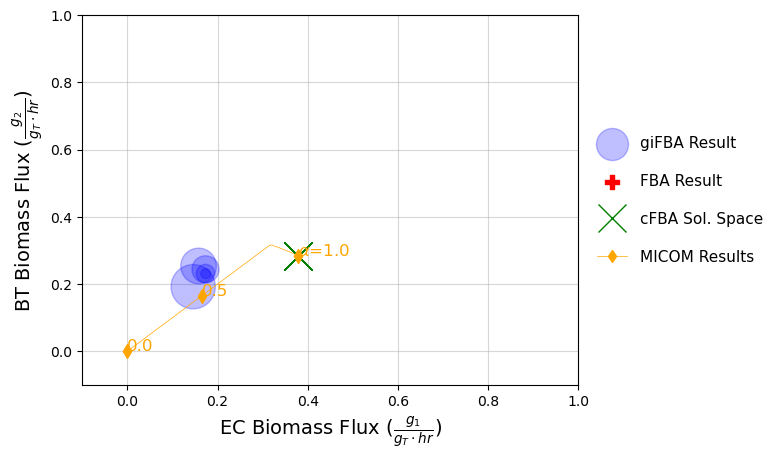

In [7]:
#plot model results

# sizes for markers
fba_marker_size, cfba_marker_size, micom_marker_size = 100, 20, 50
gifba_marker_sizes = np.linspace(18, 4, community.iters)**2 * np.pi
micom_line_width = 0.5
colors = ["b", "r", "g", "orange", "purple"] # gifba, FBA, cFBA, MICOM


# plot giFBA results
bio1_gifba = community.org_fluxes.loc[0, :]["EX_biomass(e)"]
bio2_gifba = community.org_fluxes.loc[1, :]["EX_biomass(e)"]
plt.scatter(bio1_gifba, bio2_gifba, 
            color=colors[0],
            marker="o", 
            s=gifba_marker_sizes, 
            alpha=0.25,
            label="giFBA Result",
            zorder = 2)

# compared to cobrapy FBA
plt.scatter(bio1_fba, bio2_fba, 
            color=colors[1], 
            marker="P", 
            s=fba_marker_size,
            label='FBA Result',
            zorder=3)


# compared to cFBA
plt.plot(cfba_results["First_Org_Flux"], cfba_results["Second_Org_Max_Flux"],
            color=colors[2], 
            marker="x",
            ms=cfba_marker_size,
            lw=0,
            label='cFBA Sol. Space',
            zorder=3)

# import plotting helper module
import sys
import os
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
import plotting_module as pm
        
# compared to MICOM (both interpretations)
pm.plot_micom_tradeoff_pts(micom_results, 
                           "relative", 
                           [0.0, 0.5, 1.0], # alpha tradeoffs to add text labels to
                           community.rel_abund, 
                           colors[3], 
                           micom_marker_size, 
                           micom_line_width, 
                           [(0, 0), (-0, 0), (0, 0)]) # x, y offsets for text labels

# create custom legend entry
micom_rel_handle = plt.Line2D([0], [0], color=colors[3], lw=micom_line_width, marker="d", label='MICOM Results (Rel. Rates)')
handles, labels = plt.gca().get_legend_handles_labels() # pull original legend
handles.append(micom_rel_handle) # add new legend entry
labels.append("MICOM Results") # add new legend entry
plt.legend(handles=handles, labels=labels,
           fontsize=11, loc='center right', bbox_to_anchor=(1.4, 0.5), ncol=1, frameon=False, labelspacing=1.5) 

# annotate
axis_lab_size = 14
plt.grid(zorder=0, alpha=0.5)
plt.xlabel(r"EC Biomass Flux ($\frac{g_1}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.ylabel(r"BT Biomass Flux ($\frac{g_2}{g_T \cdot hr}$)", fontsize=axis_lab_size)
plt.xlim(-0.1, 1)
plt.ylim(-0.1, 1)

plt.savefig("../figures/real_model_figs/paper_figs/1_ecoli_btheta.svg", bbox_inches='tight')